# B1, b2, b3 Comparison: 200 GeV Extended vs 26 GeV Extended

## Objective

Compare the main field **B1** (T), normal quadrupole **b2** (units), and normal
sextupole **b3** (units) at two operating points:

- **Injection before MD1** (~301 A, 26 GeV) -- the MD1 injection plateau
- **Top of SFTPRO** (~4815 A, 400 GeV) -- the SFTPRO flat-top

for two measurement campaigns on the same SPS MBB dipole:

| Dataset | Path | Description |
|---------|------|-------------|
| **200 GeV extended** | `01_200_extended` | Extended measurement, 200 GeV cycle |
| **26 GeV extended** | `03_26_extended` | Extended measurement, 26 GeV cycle |

Both share the supercycle **LHC_pilot -> MD1 -> SFTPRO** (~20 repetitions)
but were measured in separate sessions (~30 min apart).

### Settling Correction

At injection (~301 A), each supercycle has ~24 turns. The first few are
contaminated by eddy-current settling. This notebook keeps only the
**last N_LAST_TURNS_INJ** turns per supercycle and removes outliers via
MAD-based sigma clipping on B1.

---
## 1. Configuration

In [1]:
SESSION_200 = "2026_02_06/01_200_extended/20260206_144537_SPS_MBB"
SUBDIR_200  = "20260206_144559_MBB"
SESSION_26 = "2026_02_06/03_26_extended/20260206_151808_SPS_MBB"
SUBDIR_26  = "20260206_151827_MBB"

SEGMENT = "NCS"
KN_CROSS_SESSION = "20251212_171026_SPS_MBA/CRMMMMH_AV-00000001/Kn_values_Seg_Main_A_AC.txt"
MAGNET_ORDER = 1
R_REF = 0.02
SAMPLES_PER_TURN = 1024
OPTIONS = ("dri", "rot", "cel", "fed")
PLATEAU_I_RANGE_MAX = 2.5
MIN_B1_T = 1e-4
N_LAST_TURNS_INJ = 18
N_LAST_TURNS_HIGH = None
N_SIGMA_CLIP = 5
FLIP_FIELD_SIGN = False

print("B1 / b2 / b3 Comparison: 200 GeV vs 26 GeV Extended")
print("=" * 55)
print(f"  200 GeV : {SESSION_200}")
print(f"  26 GeV  : {SESSION_26}")
print(f"  Segment : {SEGMENT}")
print(f"  N_LAST_TURNS_INJ  = {N_LAST_TURNS_INJ}")
print(f"  N_SIGMA_CLIP      = {N_SIGMA_CLIP}")

B1 / b2 / b3 Comparison: 200 GeV vs 26 GeV Extended
  200 GeV : 2026_02_06/01_200_extended/20260206_144537_SPS_MBB
  26 GeV  : 2026_02_06/03_26_extended/20260206_151808_SPS_MBB
  Segment : NCS
  N_LAST_TURNS_INJ  = 18
  N_SIGMA_CLIP      = 5


---
## 2. Imports

In [2]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib widget
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists(): break
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range, detect_plateau_turns, classify_current,
    find_contiguous_groups, process_kn_pipeline, build_harmonic_rows,
    mad_sigma_clip, diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

KN_PATH = REPO_ROOT / "measurements" / KN_CROSS_SESSION
assert KN_PATH.exists(), f"Kn file not found: {KN_PATH}"
kn = load_segment_kn_txt(str(KN_PATH))
print(f"Kn loaded: {len(kn.orders)} harmonics from {KN_PATH.name}")
print("Imports ready.")

Kn loaded: 15 harmonics from Kn_values_Seg_Main_A_AC.txt
Imports ready.


---
## 3. cel/fed Safety Diagnostic

In [3]:
Ns = SAMPLES_PER_TURN
m = MAGNET_ORDER
FILE_PAT = re.compile(r"Run_(\d+)_I_([\d.]+)A_(N?CS)_raw_measurement_data\.txt$")

_session_dir = REPO_ROOT / "measurements" / SESSION_200
_run_dir = _session_dir / SUBDIR_200
_ncs_files = [f for f in sorted(_run_dir.iterdir()) if FILE_PAT.search(f.name) and SEGMENT in f.name]
assert _ncs_files, "No NCS raw file found"
_raw = np.loadtxt(_ncs_files[0])
_n_turns = _raw.shape[0] // Ns; _n_keep = _n_turns * Ns

_t_all = _raw[:_n_keep, 0].reshape(_n_turns, Ns)
_flux_abs = _raw[:_n_keep, 1].reshape(_n_turns, Ns)
_flux_cmp = _raw[:_n_keep, 2].reshape(_n_turns, Ns)
_I_all = _raw[:_n_keep, 3].reshape(_n_turns, Ns)

_I_mean_quick = _I_all.mean(axis=1)
_best_turn = np.argmax(np.abs(_I_mean_quick))
_r1 = robust_range(_raw[_best_turn*Ns:(_best_turn+1)*Ns, 1])
_r2 = robust_range(_raw[_best_turn*Ns:(_best_turn+1)*Ns, 2])
if _r2 > _r1:
    _flux_abs = _raw[:_n_keep, 2].reshape(_n_turns, Ns)
    _flux_cmp = _raw[:_n_keep, 1].reshape(_n_turns, Ns)

_I_mean = _I_all.mean(axis=1)
_hi_mask = np.abs(_I_mean) > 4000
if _hi_mask.sum() < 5: _hi_mask = np.abs(_I_mean) > np.percentile(np.abs(_I_mean), 90)
_n_diag = min(100, int(_hi_mask.sum()))
_hi_idx = np.where(_hi_mask)[0][:_n_diag]

diag = diagnose_cel_fed(_flux_abs[_hi_idx], _flux_cmp[_hi_idx],
    _t_all[_hi_idx], _I_all[_hi_idx], kn=kn, r_ref=R_REF, magnet_order=MAGNET_ORDER)
print(f"cel/fed diagnostic ({_n_diag} high-I turns from 200 GeV):")
print(f"  {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _session_dir, _run_dir, _ncs_files, _raw, _n_turns, _n_keep
del _t_all, _flux_abs, _flux_cmp, _I_all, _I_mean_quick, _best_turn
del _r1, _r2, _I_mean, _hi_mask, _n_diag, _hi_idx, _Bd

if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")

cel/fed diagnostic (100 high-I turns from 200 GeV):
  UNSAFE
  100/100 turns (100%) have |zR| > 0.0100 (median 0.0514, max 0.0930). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 2.0994e-02 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


---
## 4. Helper: Load & Process One Dataset

In [4]:
N_BLOCKS = 10
ANALYSIS_LABELS = {"injection", "flat-mid", "flat-high"}

def load_and_process(session, meas_subdir, dataset_label=""):
    session_dir = REPO_ROOT / "measurements" / session
    run_dir = session_dir / meas_subdir
    ncs_files = [f for f in sorted(run_dir.iterdir()) if FILE_PAT.search(f.name) and SEGMENT in f.name]
    assert ncs_files, f"No {SEGMENT} raw files in {run_dir}"
    raw_file = ncs_files[0]
    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_label or session}")
    print(f"  Raw file: {raw_file.name}")

    raw = np.loadtxt(raw_file)
    n_turns = raw.shape[0] // Ns; n_keep = n_turns * Ns
    print(f"  Shape: {raw.shape} -> {n_turns} turns")

    t_all = raw[:n_keep, 0].reshape(n_turns, Ns)
    flux_abs_all = raw[:n_keep, 1].reshape(n_turns, Ns)
    flux_cmp_all = raw[:n_keep, 2].reshape(n_turns, Ns)
    I_all = raw[:n_keep, 3].reshape(n_turns, Ns)

    I_mean_quick = I_all.mean(axis=1)
    best_turn = np.argmax(np.abs(I_mean_quick))
    r1 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 1])
    r2 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 2])
    if r2 > r1:
        flux_abs_all = raw[:n_keep, 2].reshape(n_turns, Ns)
        flux_cmp_all = raw[:n_keep, 1].reshape(n_turns, Ns)
        print("  (flux columns swapped)")

    I_mean = I_all.mean(axis=1); t_mean = t_all.mean(axis=1)
    I_range, I_blocks = compute_block_averaged_range(I_all, Ns, N_BLOCKS)
    plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
    is_plateau = plateau_info["is_plateau"]

    turn_label = np.array(["ramp"] * n_turns, dtype=object)
    for i in range(n_turns):
        if is_plateau[i]: turn_label[i] = classify_current(I_mean[i])

    for lab in ["injection", "flat-mid", "flat-high"]:
        mask = turn_label == lab; n = mask.sum()
        if n > 0:
            print(f"  {lab:12s}: {n:4d} turns, I = {I_mean[mask].mean():.1f} A")

    is_analysis = np.array([l in ANALYSIS_LABELS for l in turn_label])
    plateau_indices = np.where(is_analysis)[0]
    if len(plateau_indices) == 0:
        empty = pd.DataFrame()
        return empty, empty, [], t_mean, I_mean, turn_label, is_plateau

    result, C_merged, C_units, ok_main = process_kn_pipeline(
        flux_abs_turns=flux_abs_all[plateau_indices], flux_cmp_turns=flux_cmp_all[plateau_indices],
        t_turns=t_all[plateau_indices], I_turns=I_all[plateau_indices],
        kn=kn, r_ref=R_REF, magnet_order=m, options=OPTIONS, min_b1_T=MIN_B1_T)

    extra = [{"global_turn": int(plateau_indices[t]), "label": str(turn_label[plateau_indices[t]]),
              "I_range_A": float(I_range[plateau_indices[t]])} for t in range(len(plateau_indices))]
    rows = build_harmonic_rows(result, C_merged, C_units, ok_main, m, extra)
    df = pd.DataFrame(rows)

    if FLIP_FIELD_SIGN:
        t_cols = [c for c in df.columns if c.endswith("_T")]
        df[t_cols] *= -1

    # Group by supercycle
    inj_mask_global = (turn_label == "injection")
    sc_groups_inj = find_contiguous_groups(inj_mask_global, min_length=2)
    df["sc_idx"] = -1; settled_idx = []

    for gi, (gs, ge) in enumerate(sc_groups_inj):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "injection")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if N_LAST_TURNS_INJ is not None and len(group_rows) > N_LAST_TURNS_INJ:
            settled_idx.extend(group_rows[-N_LAST_TURNS_INJ:])
        else:
            settled_idx.extend(group_rows)

    fh_mask_global = (turn_label == "flat-high")
    sc_groups_fh = find_contiguous_groups(fh_mask_global, min_length=2)
    for gi, (gs, ge) in enumerate(sc_groups_fh):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "flat-high")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if N_LAST_TURNS_HIGH is not None and len(group_rows) > N_LAST_TURNS_HIGH:
            settled_idx.extend(group_rows[-N_LAST_TURNS_HIGH:])
        else:
            settled_idx.extend(group_rows)

    df_settled = df.loc[sorted(settled_idx)].copy()
    n_before = len(df_settled)
    df_settled, clip_removed = mad_sigma_clip(df_settled, "B1_T", N_SIGMA_CLIP, label_col="label")
    n_clipped = n_before - len(df_settled)
    if n_clipped > 0:
        print(f"  Sigma clip: removed {n_clipped} turns ({clip_removed})")

    n_inj_set = len(df_settled[df_settled["label"] == "injection"])
    n_fh_set = len(df_settled[df_settled["label"] == "flat-high"])
    print(f"  Final settled: injection {n_inj_set}, flat-high {n_fh_set}")

    return df, df_settled, sc_groups_inj, t_mean, I_mean, turn_label, is_plateau

---
## 5. Load Both Datasets

In [5]:
df_200, dfs_200, sc_200, t_200, I_200, lbl_200, plat_200 = load_and_process(
    SESSION_200, SUBDIR_200, "200 GeV Extended")
df_26, dfs_26, sc_26, t_26, I_26, lbl_26, plat_26 = load_and_process(
    SESSION_26, SUBDIR_26, "26 GeV Extended")


  Dataset: 200 GeV Extended
  Raw file: 20260206_144559_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt


  Shape: (1086464, 5) -> 1061 turns
  injection   :  488 turns, I = 300.9 A
  flat-high   :   74 turns, I = 4814.5 A
  Final settled: injection 360, flat-high 72

  Dataset: 26 GeV Extended
  Raw file: 20260206_151827_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt


  Shape: (1089536, 5) -> 1064 turns
  injection   :  520 turns, I = 300.9 A
  flat-high   :   72 turns, I = 4814.5 A
  Sigma clip: removed 3 turns ({'injection': 3})
  Final settled: injection 357, flat-high 69


---
## 6. Current Profile Overview

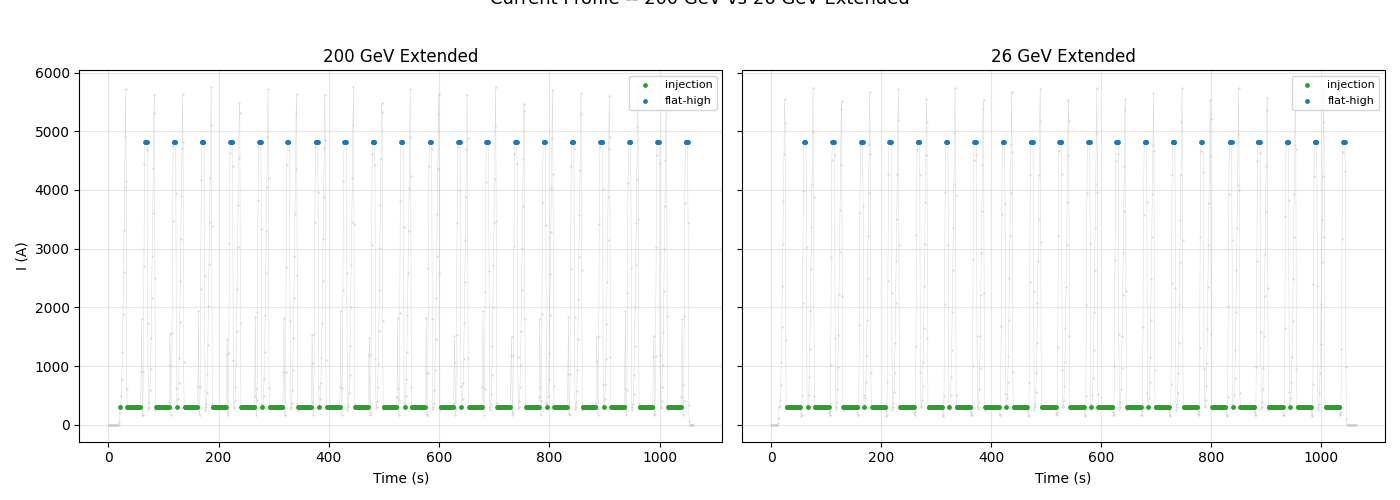

In [6]:
label_colors = {"injection": "tab:green", "flat-mid": "tab:purple", "flat-high": "tab:blue"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, t_m, I_m, lbl, plat, title in [
    (axes[0], t_200, I_200, lbl_200, plat_200, "200 GeV Extended"),
    (axes[1], t_26, I_26, lbl_26, plat_26, "26 GeV Extended")]:
    ax.plot(t_m, I_m, ".-", markersize=1, linewidth=0.3, color="lightgrey", zorder=0)
    for lab, col in label_colors.items():
        mask = lbl == lab; idx = np.where(mask)[0]
        if len(idx) > 0: ax.scatter(t_m[idx], I_m[idx], s=6, color=col, zorder=2, label=lab)
    ax.set_xlabel("Time (s)"); ax.set_title(title); ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("I (A)")
fig.suptitle("Current Profile -- 200 GeV vs 26 GeV Extended", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 7. Per-Supercycle Injection Harmonics

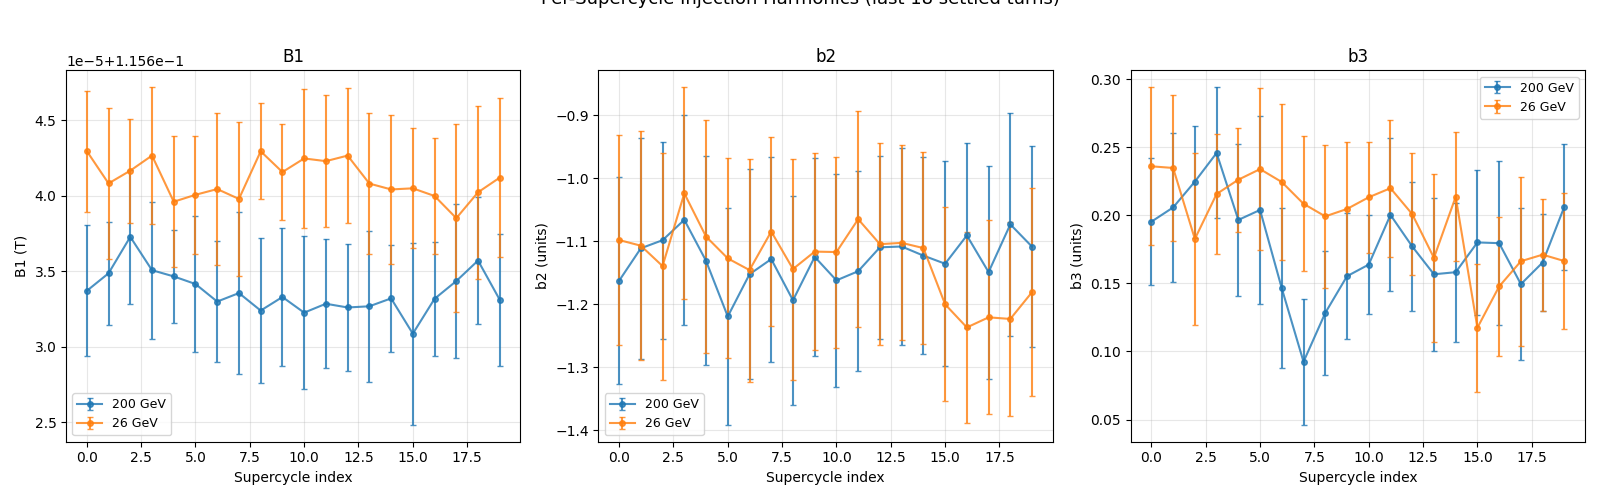

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
harmonics = [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]
for ax, (col_name, ylabel) in zip(axes, harmonics):
    for ds_name, dfs, col in [("200 GeV", dfs_200, "tab:blue"), ("26 GeV", dfs_26, "tab:orange")]:
        inj = dfs[(dfs["label"] == "injection") & dfs["ok_main"]]
        if len(inj) == 0: continue
        sc_avg = inj.groupby("sc_idx")[col_name].agg(["mean", "std"]).reset_index()
        ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                    fmt="o-", markersize=4, capsize=2, color=col, alpha=0.8, label=ds_name)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
axes[0].set_title("B1"); axes[1].set_title("b2"); axes[2].set_title("b3")
fig.suptitle(f"Per-Supercycle Injection Harmonics (last {N_LAST_TURNS_INJ} settled turns)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 8. SFTPRO Flat-Top: Effect of Preceding MD1

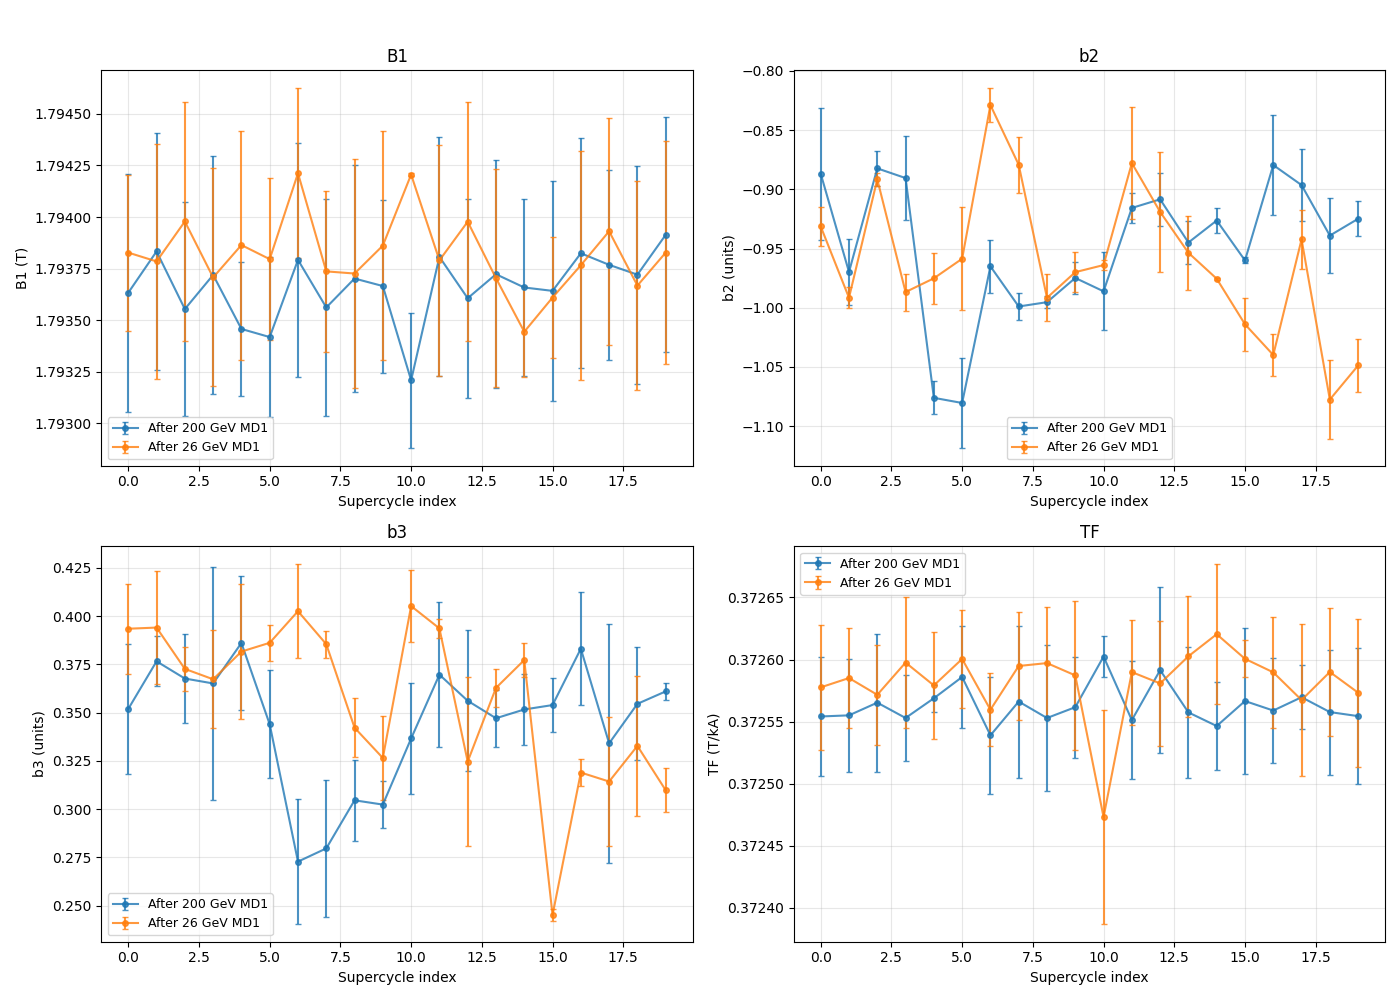

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col_name, ylabel) in zip(axes.ravel(),
    [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)"), ("TF_TperkA", "TF (T/kA)")]):
    for ds_name, dfs, col in [("After 200 GeV MD1", dfs_200, "tab:blue"), ("After 26 GeV MD1", dfs_26, "tab:orange")]:
        fh = dfs[(dfs["label"] == "flat-high") & dfs["ok_main"]].copy()
        if len(fh) == 0: continue
        if col_name == "TF_TperkA": fh["TF_TperkA"] = fh["B1_T"] / (fh["I_mean_A"] / 1000.0)
        sc_avg = fh.groupby("sc_idx")[col_name].agg(["mean", "std"]).reset_index()
        ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                    fmt="o-", markersize=4, capsize=2, color=col, alpha=0.8, label=ds_name)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
axes[0,0].set_title("B1"); axes[0,1].set_title("b2"); axes[1,0].set_title("b3"); axes[1,1].set_title("TF")
fig.suptitle("SFTPRO Flat-Top: After 200 GeV MD1 vs After 26 GeV MD1", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 9. Summary Statistics

In [9]:
summary_rows = []
for ds_name, dfs in [("200 GeV", dfs_200), ("26 GeV", dfs_26)]:
    for lab, desc in [("injection", "Injection (MD1)"), ("flat-high", "Top of SFTPRO")]:
        sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
        if len(sub) == 0: continue
        tf = sub["B1_T"].mean() / (sub["I_mean_A"].mean() / 1000.0)
        summary_rows.append({
            "Dataset": ds_name, "Operating point": desc, "N turns": len(sub),
            "I mean (A)": f"{sub['I_mean_A'].mean():.1f}",
            "B1 mean (T)": f"{sub['B1_T'].mean():.6f}", "B1 std (T)": f"{sub['B1_T'].std():.6f}",
            "b2 mean": f"{sub['b2_units'].mean():+.4f}", "b2 std": f"{sub['b2_units'].std():.4f}",
            "b3 mean": f"{sub['b3_units'].mean():+.4f}", "b3 std": f"{sub['b3_units'].std():.4f}",
            "TF (T/kA)": f"{tf:.4f}",
        })
df_summary = pd.DataFrame(summary_rows)
print(f"[Settled data: last {N_LAST_TURNS_INJ} injection turns per supercycle]\n")
print(df_summary.to_string(index=False))

[Settled data: last 18 injection turns per supercycle]

Dataset Operating point  N turns I mean (A) B1 mean (T) B1 std (T) b2 mean b2 std b3 mean b3 std TF (T/kA)
200 GeV Injection (MD1)      360      300.9    0.115634   0.000005 -1.1301 0.1628 +0.1766 0.0605    0.3843
200 GeV   Top of SFTPRO       72     4814.5    1.793681   0.000472 -0.9445 0.0576 +0.3447 0.0418    0.3726
 26 GeV Injection (MD1)      357      300.9    0.115641   0.000005 -1.1325 0.1684 +0.1976 0.0593    0.3843
 26 GeV   Top of SFTPRO       69     4814.5    1.793817   0.000462 -0.9643 0.0636 +0.3554 0.0418    0.3726


---
## 10. B1, b2, b3 Comparison Plots

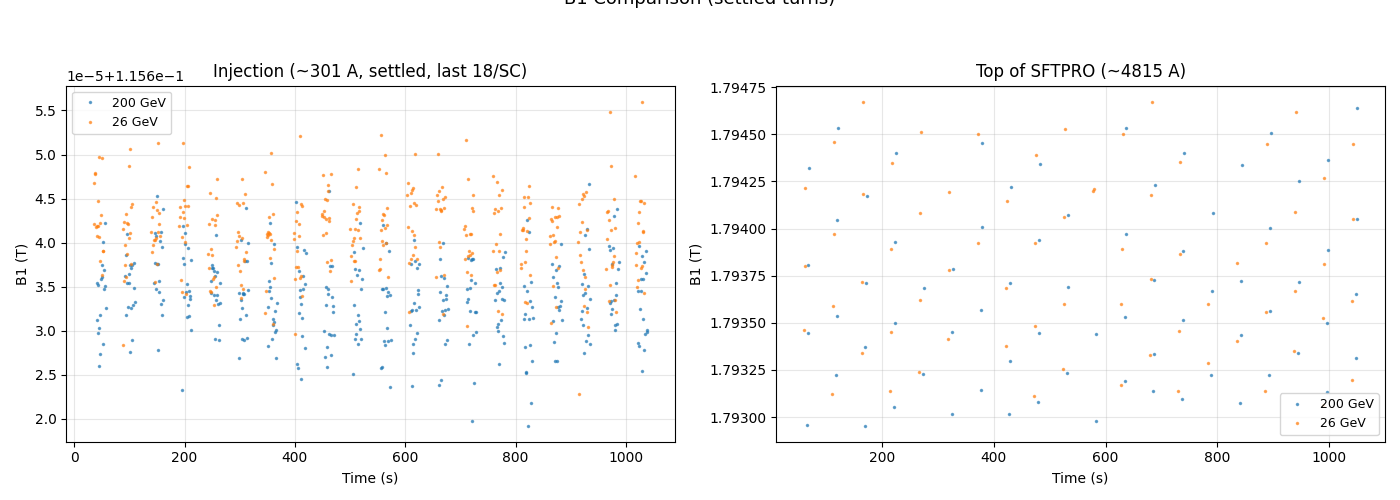

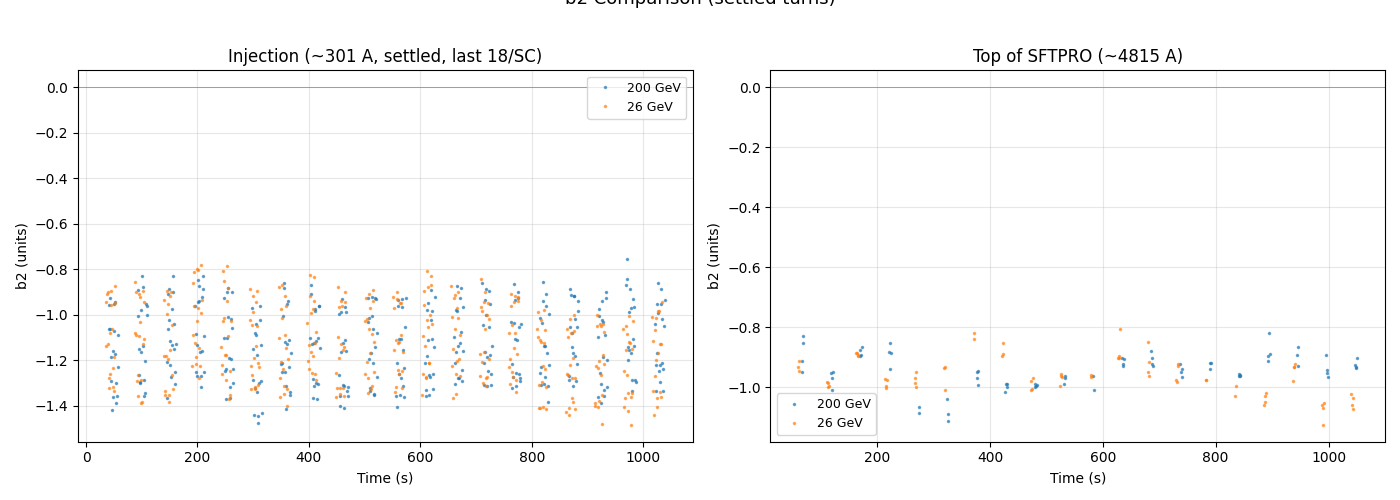

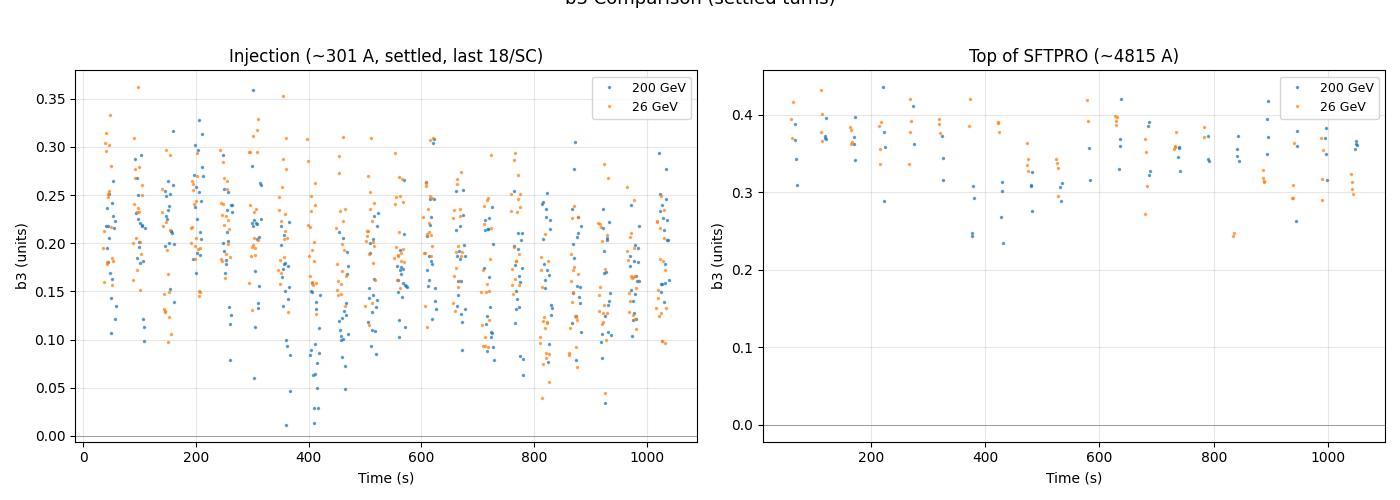

In [10]:
for harm_name, harm_col, ylabel in [("B1", "B1_T", "B1 (T)"), ("b2", "b2_units", "b2 (units)"), ("b3", "b3_units", "b3 (units)")]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, lab, title in [
        (axes[0], "injection", f"Injection (~301 A, settled, last {N_LAST_TURNS_INJ}/SC)"),
        (axes[1], "flat-high", "Top of SFTPRO (~4815 A)")]:
        for ds_name, dfs, col in [("200 GeV", dfs_200, "tab:blue"), ("26 GeV", dfs_26, "tab:orange")]:
            sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
            if len(sub) == 0: continue
            ax.plot(sub["time_s"].values, sub[harm_col].values, ".", markersize=3, alpha=0.6, color=col, label=ds_name)
        if harm_col != "B1_T": ax.axhline(0, color="grey", linewidth=0.5)
        ax.set_xlabel("Time (s)"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=9)
    fig.suptitle(f"{harm_name} Comparison (settled turns)", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

---
## 11. Box Plots

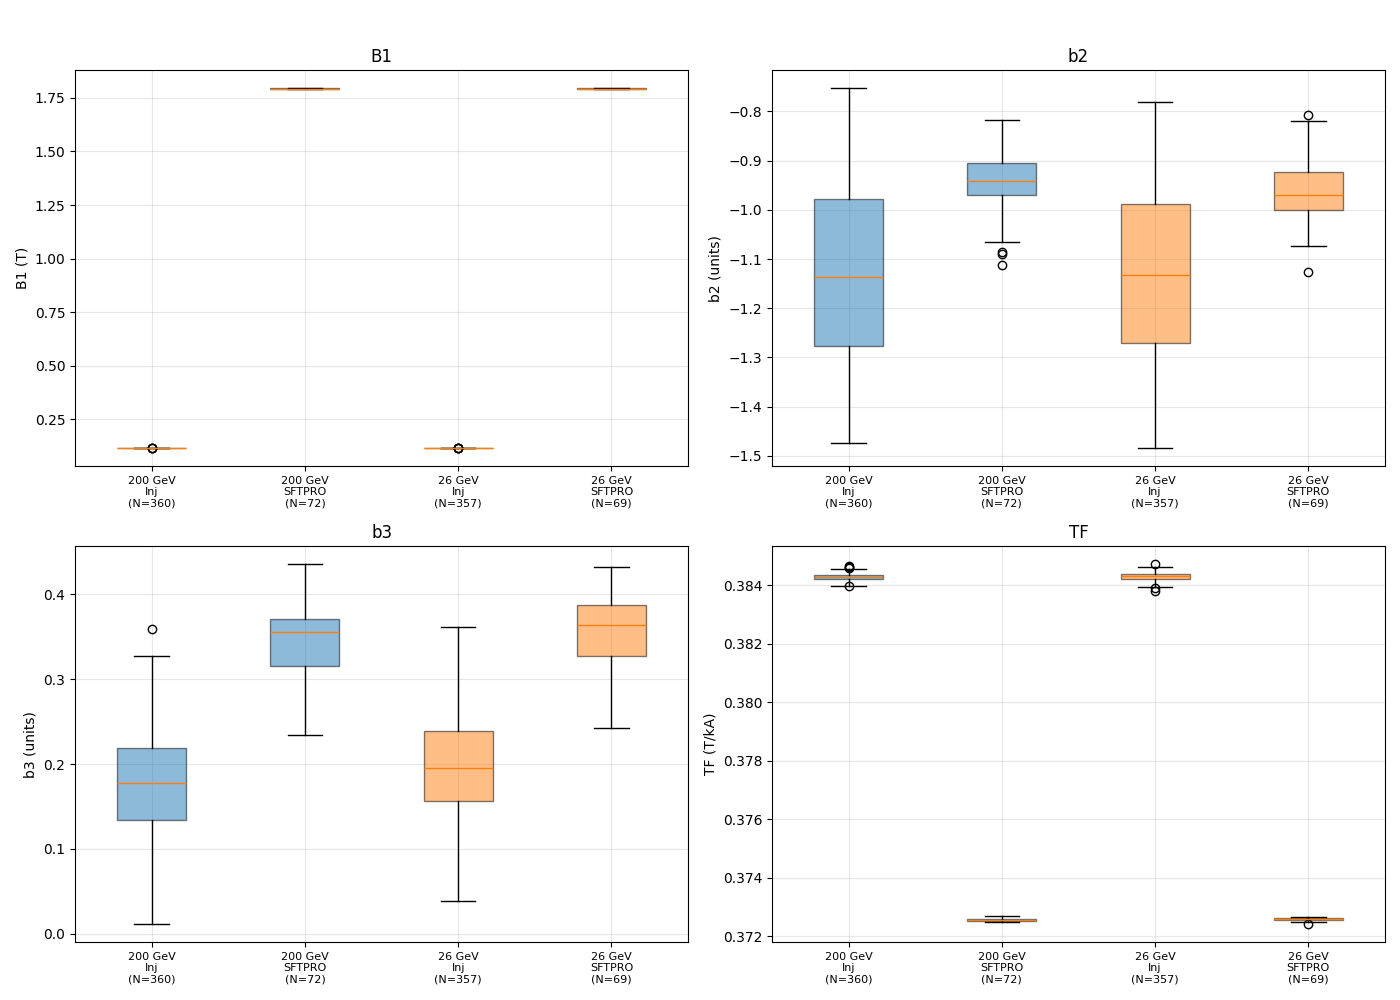

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col_name, ylabel, title) in zip(axes.ravel(),
    [("B1_T", "B1 (T)", "B1"), ("b2_units", "b2 (units)", "b2"),
     ("b3_units", "b3 (units)", "b3"), ("TF_TperkA", "TF (T/kA)", "TF")]):
    box_data, box_labels, box_colors = [], [], []
    for ds_name, dfs, base_col in [("200 GeV", dfs_200, "tab:blue"), ("26 GeV", dfs_26, "tab:orange")]:
        for lab, short in [("injection", "Inj"), ("flat-high", "SFTPRO")]:
            sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]].copy()
            if len(sub) == 0: continue
            vals = (sub["B1_T"] / (sub["I_mean_A"] / 1000.0)).values if col_name == "TF_TperkA" else sub[col_name].values
            box_data.append(vals); box_labels.append(f"{ds_name}\n{short}\n(N={len(sub)})"); box_colors.append(base_col)
    if box_data:
        bp = ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
        for patch, col in zip(bp["boxes"], box_colors): patch.set_facecolor(col); patch.set_alpha(0.5)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Distribution Comparison (settled turns)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 12. Statistical Significance

Sigma = |diff| / sqrt(std1^2/N1 + std2^2/N2). > 3 sigma = real difference.

In [12]:
print(f"Difference: (200 GeV) - (26 GeV)  [settled, last {N_LAST_TURNS_INJ}/SC at injection]")
print("=" * 100)
results = []
for lab, desc in [("injection", "Injection (~301 A)"), ("flat-high", "SFTPRO (~4815 A)")]:
    s200 = dfs_200[(dfs_200["label"] == lab) & dfs_200["ok_main"]]
    s26 = dfs_26[(dfs_26["label"] == lab) & dfs_26["ok_main"]]
    if len(s200) == 0 or len(s26) == 0: continue

    dB1 = s200["B1_T"].mean() - s26["B1_T"].mean()
    db2 = s200["b2_units"].mean() - s26["b2_units"].mean()
    db3 = s200["b3_units"].mean() - s26["b3_units"].mean()
    tf200 = s200["B1_T"].mean() / (s200["I_mean_A"].mean() / 1000.0)
    tf26 = s26["B1_T"].mean() / (s26["I_mean_A"].mean() / 1000.0)
    dTF = tf200 - tf26

    dB1_err = np.sqrt((s200["B1_T"].std()**2/len(s200)) + (s26["B1_T"].std()**2/len(s26)))
    db2_err = np.sqrt((s200["b2_units"].std()**2/len(s200)) + (s26["b2_units"].std()**2/len(s26)))
    db3_err = np.sqrt((s200["b3_units"].std()**2/len(s200)) + (s26["b3_units"].std()**2/len(s26)))
    tf200_vals = s200["B1_T"] / (s200["I_mean_A"] / 1000.0)
    tf26_vals = s26["B1_T"] / (s26["I_mean_A"] / 1000.0)
    dTF_err = np.sqrt((tf200_vals.std()**2/len(s200)) + (tf26_vals.std()**2/len(s26)))

    sig_B1 = abs(dB1)/dB1_err if dB1_err > 0 else 0
    sig_b2 = abs(db2)/db2_err if db2_err > 0 else 0
    sig_b3 = abs(db3)/db3_err if db3_err > 0 else 0
    sig_TF = abs(dTF)/dTF_err if dTF_err > 0 else 0

    print(f"{desc:>30s}  dB1={dB1:+.6f}+/-{dB1_err:.6f}  db2={db2:+.4f}+/-{db2_err:.4f}  "
          f"db3={db3:+.4f}+/-{db3_err:.4f}  dTF={dTF:+.4f}+/-{dTF_err:.4f}")
    print(f"{'(sigma)':>30s}  {sig_B1:>12.1f}  {sig_b2:>14.1f}  {sig_b3:>14.1f}  {sig_TF:>14.1f}")
    results.append((lab, desc, dB1, sig_B1, db2, sig_b2, db3, sig_b3, dTF, sig_TF, len(s200), len(s26)))

print("\nINTERPRETATION")
print("-" * 70)
for lab, desc, dB1, sB1, db2, sb2, db3, sb3, dTF, sTF, n200, n26 in results:
    print(f"\n  {desc}  (N: {n200} vs {n26} turns)")
    for name, diff, sig, unit in [("B1", dB1, sB1, "T"), ("b2", db2, sb2, "units"),
                                   ("b3", db3, sb3, "units"), ("TF", dTF, sTF, "T/kA")]:
        verdict = "REAL (>3 sigma)" if sig > 3 else ("suggestive (2-3 sigma)" if sig >= 2 else "no evidence (<2 sigma)")
        diff_str = f"{diff*1e6:+.1f} uT" if "T" in unit and "units" not in unit and "kA" not in unit else f"{diff:+.4f} {unit}"
        print(f"    {name:>3s}: {diff_str:>16s}  ({sig:.1f} sigma) -> {verdict}")

print("\nNOTE: high sigma = reliably detected, NOT necessarily large.")
print("Datasets measured ~30 min apart with different cycle histories.")

Difference: (200 GeV) - (26 GeV)  [settled, last 18/SC at injection]
            Injection (~301 A)  dB1=-0.000007+/-0.000000  db2=+0.0025+/-0.0124  db3=-0.0210+/-0.0045  dTF=-0.0000+/-0.0000
                       (sigma)          21.7             0.2             4.7             1.7
              SFTPRO (~4815 A)  dB1=-0.000136+/-0.000079  db2=+0.0198+/-0.0102  db3=-0.0107+/-0.0070  dTF=-0.0000+/-0.0000
                       (sigma)           1.7             1.9             1.5             2.8

INTERPRETATION
----------------------------------------------------------------------

  Injection (~301 A)  (N: 360 vs 357 turns)
     B1:          -7.4 uT  (21.7 sigma) -> REAL (>3 sigma)
     b2:    +0.0025 units  (0.2 sigma) -> no evidence (<2 sigma)
     b3:    -0.0210 units  (4.7 sigma) -> REAL (>3 sigma)
     TF:     -0.0000 T/kA  (1.7 sigma) -> no evidence (<2 sigma)

  SFTPRO (~4815 A)  (N: 72 vs 69 turns)
     B1:        -136.4 uT  (1.7 sigma) -> no evidence (<2 sigma)
     b2:    +0

---
## 13. Export

In [13]:
out_dir = REPO_ROOT / "output" / "2026_02_06" / "compare_200_vs_26"
out_dir.mkdir(parents=True, exist_ok=True)

for name, df in [("200GeV", df_200), ("26GeV", df_26)]:
    if len(df) > 0:
        fname = f"plateau_harmonics_{name}.csv"
        df.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(df)} rows)")

for name, dfs in [("200GeV", dfs_200), ("26GeV", dfs_26)]:
    if len(dfs) > 0:
        fname = f"plateau_harmonics_{name}_settled.csv"
        dfs.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(dfs)} rows)")

for name, dfs in [("200GeV", dfs_200), ("26GeV", dfs_26)]:
    inj = dfs[(dfs["label"] == "injection") & dfs["ok_main"]].copy()
    if len(inj) > 0:
        inj["TF_TperkA"] = inj["B1_T"] / (inj["I_mean_A"] / 1000.0)
        sc_summary = inj.groupby("sc_idx").agg(
            B1_mean=("B1_T", "mean"), B1_std=("B1_T", "std"),
            b2_mean=("b2_units", "mean"), b2_std=("b2_units", "std"),
            b3_mean=("b3_units", "mean"), b3_std=("b3_units", "std"),
            TF_mean=("TF_TperkA", "mean"), TF_std=("TF_TperkA", "std"),
            I_mean=("I_mean_A", "mean"), n_turns=("B1_T", "count"),
        ).reset_index()
        fname = f"per_supercycle_injection_{name}.csv"
        sc_summary.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(sc_summary)} rows)")

if len(df_summary) > 0:
    df_summary.to_csv(out_dir / "summary_comparison_settled.csv", index=False)
    print(f"Wrote summary_comparison_settled.csv  ({len(df_summary)} rows)")
print("\nDone.")

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_200GeV.csv  (562 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_26GeV.csv  (592 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_200GeV_settled.csv  (432 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_26GeV_settled.csv  (426 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\per_supercycle_injection_200GeV.csv  (20 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\per_supercycle_injection_26GeV.csv  (20 rows)
Wrote summary_comparison_settled.csv  (4 rows)

Done.
